## Кейс: прогнозирование метрики при помощи ARIMA

<b>Задача:</b> спрогнозировать значение числителя метрики Average Revenue Per Client (ARPC) для представления прогноза как ориентира в BI-отчетности (высокая точность не важна)

<b>Метрика:</b>

$$
ARPC = \frac{\text{Выручка за 12 месяцев}}{\text{Число уникальных клиентов за 12 месяцев}}
$$

<b>Выбранный метод:</b> ARIMA

<b>Результат прогнозирования:</b> Модель не выявила выраженной автокорреляционной структуры в данных, что обусловлено следующими факторами:
* Специфика метрики: ARPC рассчитывался как отношение прогнозируемых значений выручки и клиентской базы, что снижает стабильность и предсказуемость результирующего ряда
* Характер временного ряда: выручка, рассчитанная скользящим окном за 12 месяцев, представляет собой сглаженную монотонно возрастающую динамику без выраженной сезонности и краткосрочных флуктуаций
* Ограниченный объем данных: в распоряжении модели находилось 37 месячных наблюдений, что ограничивает возможность выявления устойчивых закономерностей
* Результаты backtest: модель корректно воспроизводит общий тренд, однако не способна улавливать краткосрочные колебания

В связи с этим прогноз отражает инерционное продолжение текущего тренда и может использоваться для иллюстрации динамики показателя, однако не рекомендуется для применения в финансовом планировании и принятии управленческих решений.

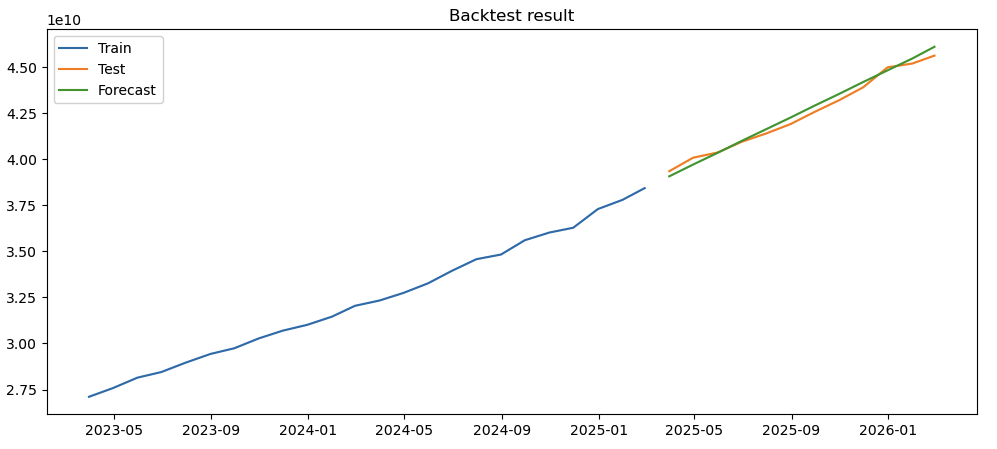

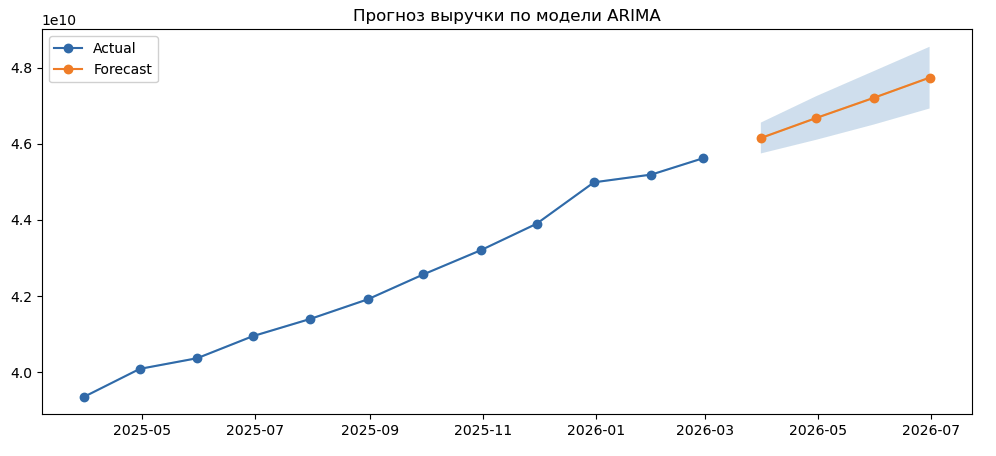

-----

### Теоретическая база

ARIMA (Autoregressive Integrated Moving Average) — это статистический метод анализа и прогнозирования нестационарных временных рядов, основанный на использовании прошлых значений данных. Она моделирует зависимость текущего значения от предыдущих (авторегрессия), разностей рядов (интеграция) и ошибок прогноза (скользящее среднее). ARIMA обозначается как ARIMA(p,d,q)

ARIMA задается несколькими следующими параметрами:
* p (AutoRegressive, AR): порядок авторегрессии — количество предыдущих наблюдений, влияющих на текущее значение.
* d (Integrated, I): порядок интегрирования — количество дифференцирований (взятий разностей) ряда для приведения его к стационарному виду.
* q (Moving Average, MA): порядок скользящего среднего — количество прошлых ошибок прогноза, учитываемых в текущей модели.

SARIMA - это подкласс модели ARIMA, главным образом отличается тем, что модель предстказания делится на 2 составные части: ARIMA и сезонность (S).

Так, в SARIMA, помимо указанных выше параметров, добавляются дополнительные параметры P,D,Q, отвечающие за сезонную часть предсказания модели

$$
y_t = \sum_{i=1}^p \phi_i y_{t-i} + \sum_{j=1}^P \Phi_j y_{t-j \cdot s} + \sum_{k=1}^q \theta_k \varepsilon_{t-k} + \sum_{m=1}^Q \Theta_m \varepsilon_{t-m \cdot s} + \varepsilon_t
$$

где

* $y_t$ - значение метрики в текущий момент времени
* $y_{t-i}$ - значение метрики i периодов назад
* $y_{t-j \cdot s}$ - значение метрики в тот же период прошлого сезона
* $\varepsilon_t$ - ошибка модели в текущий момент
* $\varepsilon_{t-k}$ - ошибка модели k периодов назад
* $\varepsilon_{t-m \cdot s}$ - ошибка модели в тот же период прошлого сезона
* $\phi_i$ - насколько прошлое значение влияет на текущее
* $\Phi_j$ - насколько влияет значение год назад
* $\theta_k$ - вес влияния прошлой ошибки
* $\Theta_m$ - вес влияния сезонной ошибки $\varepsilon_{t-m \cdot s}$

<b> Разберем каждый парметр модели по-отдельности

* Модель авторегрессионная (AR, p) - означает, что для построения регрессии используются прошлые данные той же метрики, для которой строится прогноз
* Модель интегрированная (I, d) - означает, что для нестационарных начальных данных производится дифференцирование для приведения его к стационарному виду
* Скользящее среднее (MA, q) - учитывает автокорреляцию ошибок модели. Она позволяет корректировать прогноз на основе прошлых отклонений факта от прогноза, особенно при наличии краткосрочных шоков.

Резюме:
* $p$ - сколько прошлых значений y используется (AR)
* $P$ - сколько сезонных лагов используется
* $q$ - сколько прошлых ошибок используется (MA)
* $Q$ - сколько сезонных ошибок используется
* $s$ - это длина сезона: 7 = неделя, 12 = месячные данные
* $d$ - количество дифференциаций начальной метрики для приведения временного ряда к стационарности

In [505]:
# Импорт библиотек и загрузка данных
import pandas as pd
import numpy as np
df = pd.read_csv('arima_data.csv', decimal=',')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   metrics  77 non-null     object
 1   dt       77 non-null     object
 2   est      77 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.9+ KB


In [507]:
# Приведение данных к нужному типу
df['dt'] = pd.to_datetime(df['dt'])
df['est'] = pd.to_numeric(df['est'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   metrics  77 non-null     object        
 1   dt       77 non-null     datetime64[ns]
 2   est      77 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.9+ KB


In [509]:
# Проверка наличия NULL
df.isna().sum()

metrics    0
dt         0
est        0
dtype: int64

In [530]:
revenue_data = df.copy()
revenue_data = revenue_data[revenue_data['metrics'] == 'Выручка_12']
revenue_data['date'] = pd.to_datetime(revenue_data['dt'])
revenue_data = revenue_data.set_index('dt')

ts = revenue_data['est']
revenue_data.head(3)

,metrics,est,date
dt,,,
2023-01-31,Выручка_12,26279845654,2023-01-31
2023-02-28,Выручка_12,26644529392,2023-02-28
2023-03-31,Выручка_12,27108694812,2023-03-31


### Проверка стационарности
Проблема нестационарного временного ряда: если ряд нестационарен, каждая точка на графике имеет разное среднее и дисперсию, а значит и принадлежат каждая своему распределению. Модель не сможет сделать корректное предсказание

Временной ряд стационарен, если он не демонстрирует какой-либо долгосрочный тренд или сезонность
* Неизменная дисперсия всо все временные отрезки
* Неизменное среднее с течением времени

Для проверки стационарности можно:
* Построить график, визуально оценить дисперсию и среднее
* Провести статистический тест (ADF-тест)

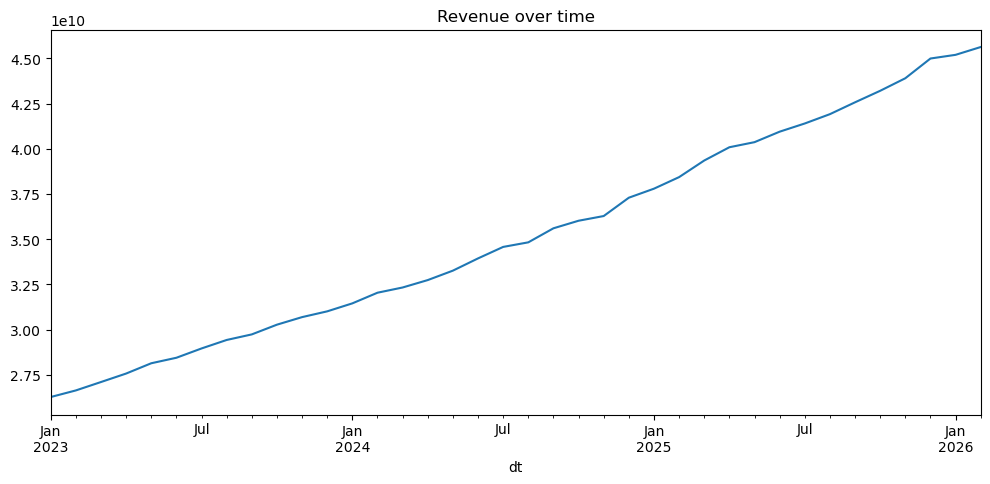

In [533]:
import matplotlib.pyplot as plt

revenue_data['est'].plot(figsize=(12,5), x = df['dt'])
plt.title('Revenue over time')
plt.show()

Из графика уже очевидно, что ряд нестационарен, проверим дополнительно при помощи adfuller

In [536]:
from statsmodels.tsa.stattools import adfuller

# Проводим тест
def adf_test(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print(f'critical values:')
    if result[1] <= 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд НЕстационарен (принимаем H0), нужно брать разности")
    for thres, adf_stat in result[4].items():
        print(f"\t{thres}: {adf_stat:.2f}")
# ADF statisic < critical value -> level of confidence

In [538]:
adf_test(revenue_data['est'])

ADF Statistic: 2.7633693302962086
p-value: 1.0
critical values:
Ряд НЕстационарен (принимаем H0), нужно брать разности
	1%: -3.63
	5%: -2.95
	10%: -2.61


Для подбора оптимальной спецификации модели ARIMA рассматриваются различные преобразования исходного временного ряда с целью определения представления, обеспечивающего наилучшее качество моделирования:
* исходная выручка (revenue)
* преобразование Box-Cox (revenue_boxcox)
* дифференцированный ряд без Box-Cox (revenue_diff_noboxcox)
* дифференцированный ряд (revenue_diff)

В связи с этим проведем преобразования:

Text(0.5, 1.0, 'Revenue Box-Cox')

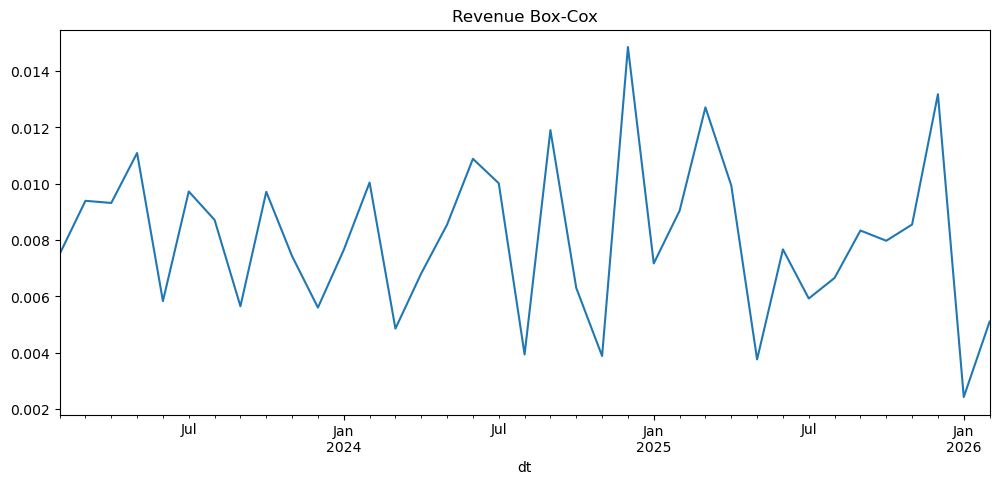

In [542]:
# 1. Box-Cox - логарифмирование
from scipy.stats import boxcox
revenue_data['est_boxcox'], lam = boxcox(revenue_data['est'])
revenue_data['revenue_diff'] = revenue_data['est_boxcox'].diff()
revenue_data.dropna(inplace = True)
revenue_data['revenue_diff'].plot(figsize=(12,5))
plt.title('Revenue Box-Cox')

Повторно проверяем стационарность при помощи adfuller

In [545]:
adf_test(revenue_data['revenue_diff'])

ADF Statistic: -5.77787482850103
p-value: 5.20812588832295e-07
critical values:
Ряд стационарен (отвергаем H0)
	1%: -3.63
	5%: -2.95
	10%: -2.61


Text(0.5, 1.0, 'Revenue Diff ')

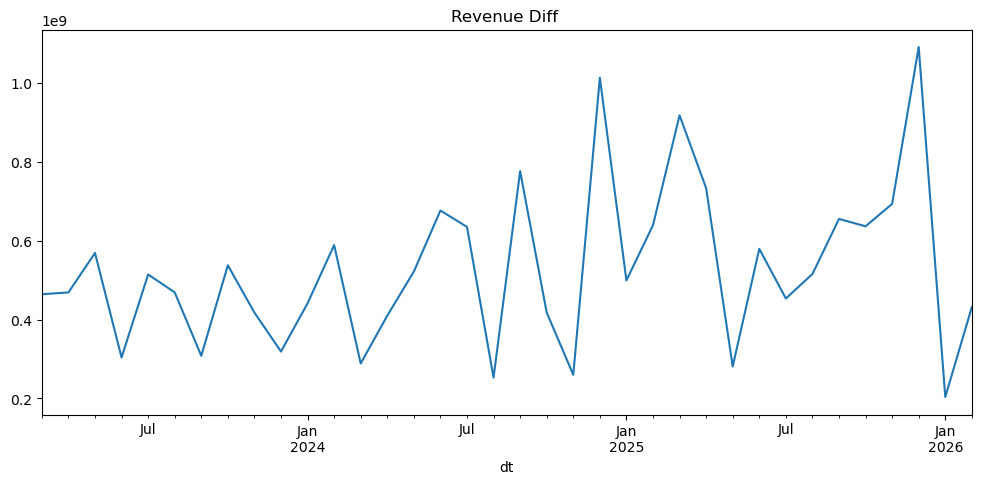

In [547]:
# 2. Дифференцирование первого порядка
revenue_data['revenue_diff_noboxcox'] = revenue_data['est'].diff()
revenue_data.dropna(inplace = True)
revenue_data['revenue_diff_noboxcox'].plot(figsize=(12,5))
plt.title('Revenue Diff ')

In [549]:
adf_test(revenue_data['revenue_diff_noboxcox'])

ADF Statistic: -6.31067188181503
p-value: 3.240537533213895e-08
critical values:
Ряд стационарен (отвергаем H0)
	1%: -3.63
	5%: -2.95
	10%: -2.61


Как можно наблюдать, оба варианта приведения к стационарности дали положительный результат.
* В Box-Cox преобразорвании p-value < 0.05
* В дифферинцировании p-value < 0.05

Однако дальнейший анализ показал, что в условиях ограниченного объема данных и специфики метрики (сглаженная динамика без выраженных флуктуаций) данные преобразования не приводят к улучшению качества прогноза, что было подтверждено результатами backtest.

В связи с этим в итоговой модели используется непреобразованный ряд выручки.

# Order selection

## Автокорреляция

ACF (Autocorrelation Function) — это функция автокорреляции. Она показывает, насколько текущее значение ряда похоже на свои прошлые значения (лаги).

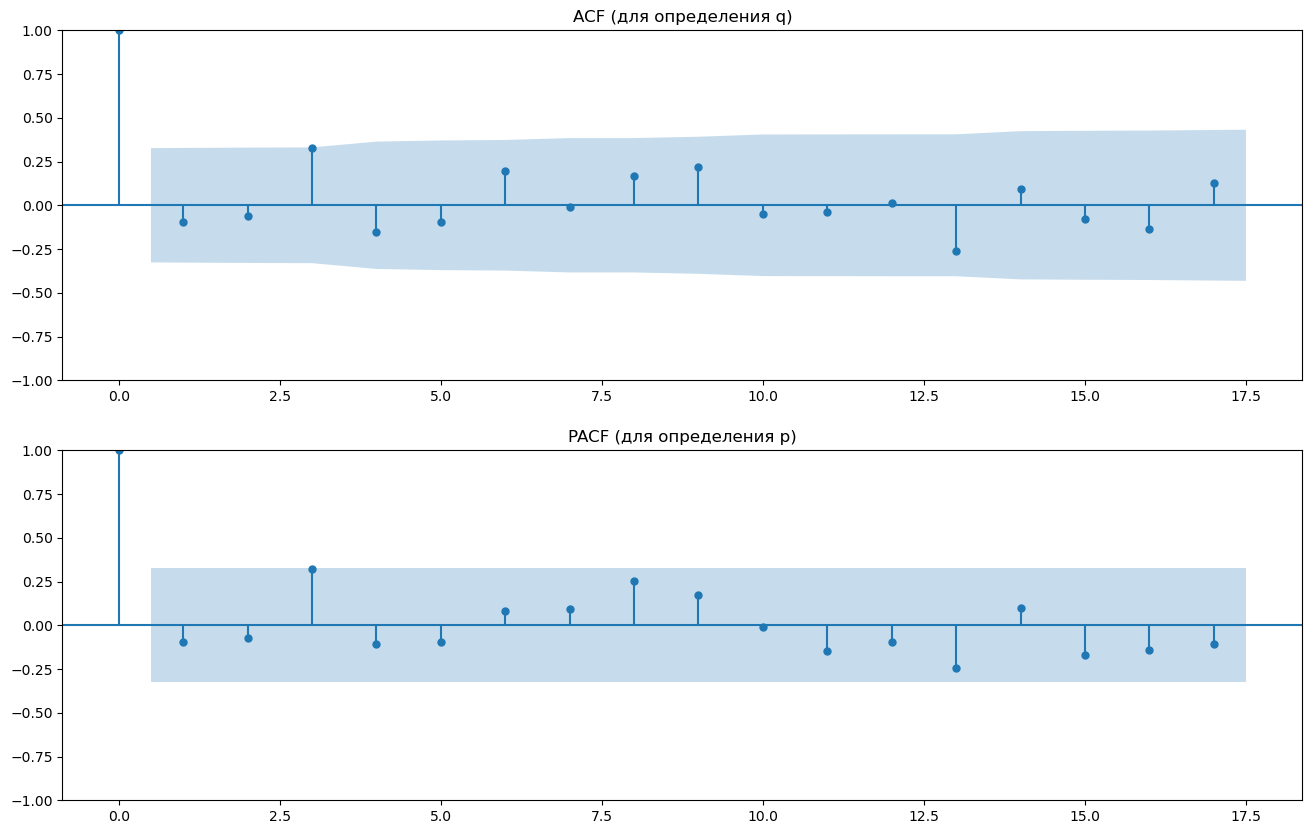

In [555]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data_to_plot = revenue_data['revenue_diff_noboxcox']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ACF помогает определить параметр q (Moving Average)
# по оси Х - дни, с которыми коррелирует текущее значение (задаем сами)
# по оси У - коэффициент корреляции Пирсона
plot_acf(data_to_plot, ax=axes[0], lags=17)
axes[0].set_title('ACF (для определения q)')

# PACF помогает определить параметр p (Autoregression)
plot_pacf(data_to_plot, ax=axes[1], lags=17, method='ywm')
axes[1].set_title('PACF (для определения p)')

plt.show()

In [557]:
from pmdarima import auto_arima

model = auto_arima(
    revenue_data['revenue_diff_noboxcox'],
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1498.050, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1555.180, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1511.200, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1541.359, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1496.865, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1541.098, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1491.688, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1492.621, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1503.756, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1487.684, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1485.686, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1483.899, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1485.593, Time=0.01 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 0.184 seconds


## Backtest

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=923.564, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=927.195, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=928.406, Time=0.01 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=921.666, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=930.978, Time=0.04 sec

Best model:  ARIMA(0,2,0)(0,0,0)[0]          
Total fit time: 0.209 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   24
Model:               SARIMAX(0, 2, 0)   Log Likelihood                -459.833
Date:                Mon, 23 Mar 2026   AIC                            921.666
Time:                        22:18:13   BIC                            922.757
Sample:                    03-31-2023   HQIC                           921.923
                    

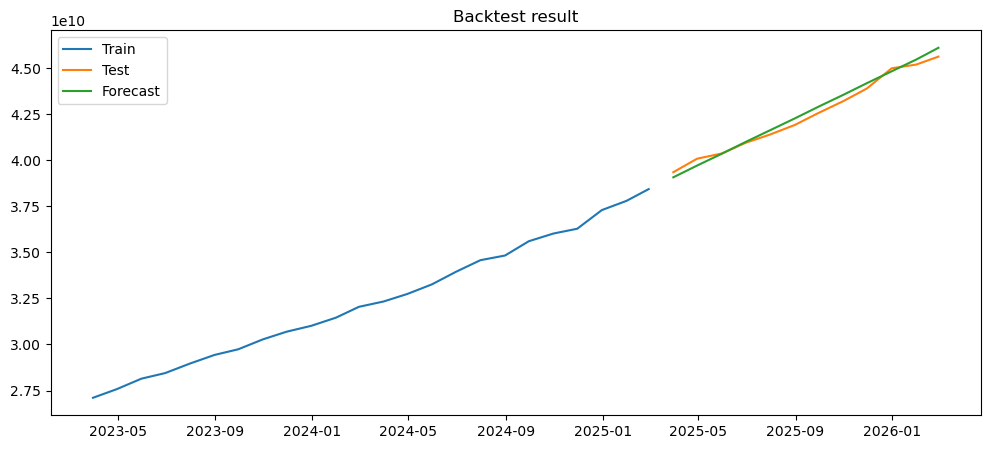

In [586]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

ts = revenue_data['est'].copy()

test_size = 12
train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

forecast = model.predict(n_periods=test_size)

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test.values - forecast) / test.values)) * 100

print(model.summary())
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.title('Backtest result')
plt.show()

### Финальная модель

In [572]:
model_final = auto_arima(
    ts,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)
forecast = model_final.predict(n_periods=6)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1451.587, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1443.682, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1447.502, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1445.739, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1512.375, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1447.580, Time=0.02 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.156 seconds


In [589]:
# Прогноз
forecast, conf_int = model_final.predict(
    n_periods=4,
    return_conf_int=True
)

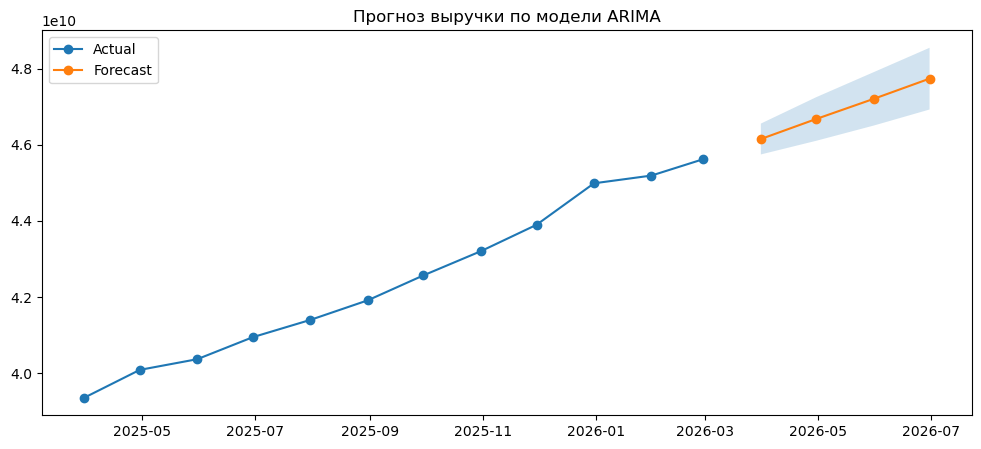

In [591]:
plt.figure(figsize=(12, 5))

# последние 12 фактических месяцев
plt.plot(ts.index[-12:], ts.values[-12:], label='Actual', marker='o')

# прогноз на 6 месяцев
plt.plot(future_index, forecast, label='Forecast', marker='o')

# доверительный интервал
plt.fill_between(
    future_index,
    conf_int[:, 0],
    conf_int[:, 1],
    alpha=0.2
)

plt.legend()
plt.title('Прогноз выручки по модели ARIMA')
plt.show()